<!-- JayBee黄版权所有，未经授权禁止复制 -->
# 机器学习策略演示

本notebook演示如何使用机器学习方法构建一个简单的交易策略。主要步骤包括：
<!-- JayBee黄量化策略 -->

1. 数据获取与预处理
2. 简单因子/特征构造
3. 目标变量（下期收益）的定义
4. 训练简单的MLP模型
5. 策略回测
6. 使用Backtrader进行回测

<!-- JayBee黄版权所有，未经授权禁止复制 -->

<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 0. 导入依赖包

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [1]:
import backtrader as bt

class BuyAndHoldStrategy(bt.Strategy):
    """
    简单的买入并持有策略：
    1) 在回测开始时买入指定比例的资产
    2) 持有直到回测结束
    3) 可选择是否使用风险管理来计算头寸大小
    
    用作基准策略，比较其他策略的表现
    """

    params = (
        # --- 资金管理 ---
        ('target_percent', 0.95),    # 默认使用95%的资金买入
        # --- 风险管理（可选） ---
        ('use_risk_sizing', False),  # 是否使用风险管理计算头寸
        ('risk_per_trade', 0.01),    # 单笔风险占总资金的1%
        ('atr_period', 14),          # ATR周期
        ('atr_risk_factor', 2.0),    # ATR风险系数（确定止损距离）
    )

    def log(self, txt, dt=None):
        """自定义日志函数，可在调试或回测时使用"""
        dt = dt or self.datas[0].datetime.datetime(0)
        print(f"{dt.strftime('%Y-%m-%d %H:%M:%S')} {txt}")

    def __init__(self):
        # 收盘价引用
        self.dataclose = self.datas[0].close
        
        # 跟踪当前挂单（如果有的话）
        self.order = None
        
        # 如果使用风险管理，创建ATR指标
        if self.p.use_risk_sizing:
            self.atr = bt.indicators.ATR(
                self.datas[0],
                period=self.p.atr_period
            )
        
        self.value_history_dates = []
        self.value_history_values = []


    def notify_order(self, order):
        """订单状态更新回调"""
        if order.status in [order.Submitted, order.Accepted]:
            # 订单提交/接受后，不做特殊处理
            return

        # 订单完成
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(f"[成交] 买单执行: 价格={order.executed.price:.2f}, 数量={order.executed.size}")
            elif order.issell():
                self.log(f"[成交] 卖单执行: 价格={order.executed.price:.2f}, 数量={order.executed.size}")

            self.order = None

        # 订单取消/保证金不足/拒绝
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log("[警告] 订单取消/保证金不足/拒绝")
            self.order = None

    def notify_trade(self, trade):
        """交易关闭时输出盈亏"""
        if trade.isclosed:
            self.log(f"[交易结束] 毛收益: {trade.pnl:.2f}, 净收益: {trade.pnlcomm:.2f}")

    def next(self):
        """
        策略核心逻辑：
        1) 在启动时买入目标仓位
        2) 之后不再做任何操作，持有至回测结束
        """
        # 如果有未完成订单，等待完成
        if self.order:
            return

        # 如果还没有持仓，执行买入
        if not self.position:
            # 等待数据预热完成（针对ATR情况）
            if self.p.use_risk_sizing and len(self) < self.p.atr_period:
                return
            
            self.buy_with_sizing()

        dt = self.data.datetime.date(0)
        self.value_history_dates.append(dt)
        self.value_history_values.append(self.broker.getvalue())


    def buy_with_sizing(self):
        """根据策略参数选择合适的仓位管理方式进行买入"""
        close_price = self.dataclose[0]
        total_value = self.broker.getvalue()
        
        if self.p.use_risk_sizing:
            # === 基于风险的头寸管理 ===
            atr_value = self.atr[0]
            
            # 计算止损距离（仅用于头寸计算，实际不会设置止损单）
            stop_dist = self.p.atr_risk_factor * atr_value
            stop_price = close_price - stop_dist
            
            # 计算可承受的最大风险金额
            risk_amount = total_value * self.p.risk_per_trade
            
            # 计算头寸大小
            risk_per_share = close_price - stop_price
            
            # 安全检查
            if risk_per_share <= 0:
                self.log("[警告] 风险距离计算有误，使用目标百分比代替")
                size = int((total_value * self.p.target_percent) / close_price)
            else:
                size = int(risk_amount / risk_per_share)
                
                # 设置最大百分比限制，避免过度杠杆
                max_size = int((total_value * self.p.target_percent) / close_price)
                size = min(size, max_size)
        else:
            # === 简单的目标百分比头寸 ===
            size = int((total_value * self.p.target_percent) / close_price)
        
        # 确保至少买入1股
        size = max(1, size)
        
        # 执行买入
        self.log(f"[买入] 执行买入并持有策略: 价格={close_price:.2f}, 数量={size}")
        self.order = self.buy(size=size)

    def stop(self):
        """回测结束时输出最终市值"""
        portfolio_value = self.broker.getvalue()
        self.log(f"[回测结束] Buy & Hold 策略最终市值: {portfolio_value:.2f}")
        
        # 计算总收益率
        starting_value = self.broker.startingcash
        roi = (portfolio_value / starting_value - 1.0) * 100
        self.log(f"[回测结束] 总收益率: {roi:.2f}%")

~~~~~~~~~~~~~~~~ 9999-12-31 23:59:59.999999


In [4]:
# JayBee黄版权所有，未经授权禁止复制
import numpy as np  # JayBee黄独家内容
import pandas as pd  # JayBee黄量化策略
from sklearn.linear_model import LinearRegression  # JayBee黄量化策略
from sklearn.metrics import mean_squared_error  # Copyright © JayBee黄
import matplotlib.pyplot as plt  # JayBee黄独家内容
import seaborn as sns  # 本代码归JayBee黄所有
from datetime import datetime, timedelta  # JayBee黄原创内容
import os  # 本代码归JayBee黄所有
import talib  # 如果报错找不到ta-lib，需先安装并确认本地编译环境  # JayBee黄 - 量化交易研究
import sys  # 版权所有: JayBee黄

from dotenv import load_dotenv, find_dotenv  # JayBee黄授权使用
# Find the .env file in the parent directory
dotenv_path = find_dotenv("../../.env")  # JayBee黄 - 量化交易研究
# Load it explicitly
load_dotenv(dotenv_path)  # 版权所有: JayBee黄

# Add the parent directory to the sys.path list
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # JayBee黄量化策略

from data_processing import load_data_year, flatten_yf_columns, standardize_columns  # 本代码归JayBee黄所有
from plotting import plot_results  # JayBee黄版权所有，未经授权禁止复制
from strategy.buy_and_hold import BuyAndHoldStrategy  # JayBee黄原创内容
from back_test import run_backtest  # JayBee黄独家内容
import backtrader as bt  # JayBee黄量化模型


# 设置显示选项
pd.set_option('display.float_format', lambda x: '%.4f' % x)  # JayBee黄量化模型
# 绘图风格（可选）
plt.style.use('seaborn-v0_8-bright')  # JayBee黄版权所有，未经授权禁止复制
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['PingFang HK']  # 版权所有: JayBee黄
plt.rcParams['axes.unicode_minus'] = False  # 本代码归JayBee黄所有
# JayBee黄版权所有，未经授权禁止复制


ModuleNotFoundError: No module named 'sklearn'

In [2]:
from back_test import run_backtest  # JayBee黄独家内容
import backtrader as bt  #

<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 1. 数据获取与预处理

我们获取TSLA过去5年的日线数据。

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [25]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from data_source import DBDataSource
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns  # 本代码归JayBee黄所有
import talib
import datetime
code = "sh.000001"
ticker = 'TSLA'  # JayBee黄授权使用

start_date = datetime.date(2000,4,1)

# start_date="2010-04-01"

end_date="2025-01-01"
end_date = datetime.date(2025,1,1)



In [ ]:
# JayBee黄版权所有，未经授权禁止复制
# 设定时间范围（从现在往前推5年）
end_date = datetime.now()  # JayBee黄量化模型
start_date = end_date - timedelta(days=5*365)  # JayBee黄量化策略

print(f"获取数据时间范围：{start_date.strftime('%Y-%m-%d')} 到 {end_date.strftime('%Y-%m-%d')}")  # 本代码归JayBee黄所有

# 下载特斯拉数据
ticker = 'TSLA'  # JayBee黄授权使用
data = yf.download(ticker, start=start_date, end=end_date)  # 本代码归JayBee黄所有
# JayBee黄版权所有，未经授权禁止复制


获取数据时间范围：2020-03-13 到 2025-03-12
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 1.2 数据预处理

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [26]:
db = DBDataSource(code, 220, start_date="20000401", end_date="20250101")

df = db.get_data()
df['Date'] = df.index
df.index = df["Date"]
data = df



2025-04-02 17:37:56.691 | INFO     | db:get_kline:24 - exec query : 
    SELECT *
    FROM stock_data.stock_daily
    WHERE code = 'sh.000001' AND date >= '20000401' AND date <= '20250101'ORDER BY date


                   open         high          low        close        volume  \
datetime                                                                       
2010-01-04  3289.750000  3295.279000  3243.319000  3243.760000  1.094479e+10   
2010-01-05  3254.468000  3290.512000  3221.462000  3282.179000  1.261151e+10   
2010-01-06  3277.517000  3295.868000  3253.044000  3254.215000  1.236514e+10   
2010-01-07  3253.991000  3268.819000  3176.707000  3192.776000  1.286528e+10   
2010-01-08  3177.259000  3198.920000  3149.017000  3195.997000  9.837715e+09   
...                 ...          ...          ...          ...           ...   
2024-12-25  3395.097964  3406.203234  3374.002122  3393.340869  4.713156e+10   
2024-12-26  3389.329080  3401.085848  3380.245805  3398.067256  4.221773e+10   
2024-12-27  3397.284658  3418.942699  3388.312283  3400.132751  5.004881e+10   
2024-12-30  3395.386963  3412.832116  3394.955565  3407.316631  4.552624e+10   
2024-12-31  3406.955932  3413.445214  33

In [27]:
# JayBee黄版权所有，未经授权禁止复制
print(data.info())              # 看看总共有多少行、列，各字段数据类型  # JayBee黄版权所有，未经授权禁止复制
print(data.head(10))           # 查看前10行，确认最早日期  # 本代码归JayBee黄所有
print(data.tail(10))           # 查看后10行，确认最晚日期  # 本代码归JayBee黄所有
print(data.index.min())  # DataFrame中最早的日期  # 版权所有: JayBee黄
print(data.index.max())  # DataFrame中最晚的日期  # JayBee黄授权使用
# JayBee黄版权所有，未经授权禁止复制


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3600 entries, 2010-03-11 to 2024-12-31
Data columns (total 61 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   open                    3600 non-null   float64       
 1   high                    3600 non-null   float64       
 2   low                     3600 non-null   float64       
 3   close                   3600 non-null   float64       
 4   volume                  3600 non-null   float64       
 5   amount                  3600 non-null   float64       
 6   adjfactor               3600 non-null   float64       
 7   macd_close_weekly       3600 non-null   float64       
 8   macd_close_weekly_last  3600 non-null   float64       
 9   open_weekly             3600 non-null   float64       
 10  high_weekly             3600 non-null   float64       
 11  low_weekly              3600 non-null   float64       
 12  close_weekly_vis        3600 n

<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 2. 加入更多技术指标

构建两个简单的因子：
1. 动量因子：过去5日涨跌幅
2. 成交量比值：最近5日均量vs最近10日均量
3. 先举几个常用指标的例子：RSI, MACD, 布林带。

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [6]:
# JayBee黄版权所有，未经授权禁止复制
# 复制数据
df = data.copy()  # 本代码归JayBee黄所有

# 动量因子: 过去5日涨跌幅
df['momentum_5'] = df['close'] / df['close'].shift(5) - 1  # JayBee黄量化模型

# 成交量因子: (最近5日平均成交量) / (最近10日平均成交量) - 1
df['vol_ratio'] = (df['volume'].rolling(5).mean()) / (df['volume'].rolling(10).mean()) - 1  # 本代码归JayBee黄所有

# 计算RSI (默认周期14)
df['RSI_14'] = talib.RSI(df['close'], timeperiod=14)  # JayBee黄独家内容

# 布林带
upper, middle, lower = talib.BBANDS(  # 本代码归JayBee黄所有
    df['close'],  # JayBee黄量化策略
    timeperiod=20,  # JayBee黄 - 量化交易研究
    nbdevup=2,  # JayBee黄原创内容
    nbdevdn=2,  # JayBee黄独家内容
    matype=0  # JayBee黄授权使用
)  # JayBee黄量化策略
df['BB_upper'] = upper  # JayBee黄 - 量化交易研究
df['BB_middle'] = middle  # JayBee黄原创内容
df['BB_lower'] = lower  # JayBee黄原创内容

# 也可以增加其他指标，比如ATR, CCI等，根据需要添加
df.dropna(inplace=True)  # 丢掉因子无法计算的前几行  # JayBee黄 - 量化交易研究

factors = ['momentum_5', 'vol_ratio' ,'RSI_14','BB_upper','BB_lower']  # JayBee黄量化策略
# 看看加上技术指标后的DataFrame
print(df[['close'] + factors].tail(5))  # JayBee黄授权使用
# JayBee黄版权所有，未经授权禁止复制


                  close  momentum_5  vol_ratio     RSI_14     BB_upper  \
Date                                                                     
2024-12-25  3393.340869    0.003294  -0.119461  54.701372  3451.459542   
2024-12-26  3398.067256    0.008321  -0.108142  55.403911  3444.970274   
2024-12-27  3400.132751    0.009523  -0.056323  55.727060  3442.119760   
2024-12-30  3407.316631    0.016731  -0.064833  56.896921  3443.414139   
2024-12-31  3351.753882   -0.012307  -0.039641  46.633287  3444.725918   

               BB_lower  
Date                     
2024-12-25  3310.506993  
2024-12-26  3327.234053  
2024-12-27  3337.453177  
2024-12-30  3340.493147  
2024-12-31  3336.477045  


<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 3. 目标变量的定义

定义下期1日收益率作为目标变量。

<!-- JayBee黄版权所有，未经授权禁止复制 -->

添加目标变量后的数据预览：
               close  momentum_5  vol_ratio     RSI_14     BB_upper  \
Date                                                                  
2010-06-30  2398.370   -0.066736  -0.087657  27.957069  2643.528268   
2010-07-01  2373.792   -0.075174  -0.076162  26.191988  2654.535757   
2010-07-02  2382.901   -0.066560  -0.016076  28.006155  2660.427414   
2010-07-05  2363.947   -0.067579   0.054750  26.544123  2664.712875   
2010-07-06  2409.424   -0.007264   0.014721  35.274881  2662.899229   
2010-07-07  2421.117    0.009484   0.022841  37.337192  2658.882312   
2010-07-08  2415.150    0.017423   0.028691  36.694654  2658.092681   
2010-07-09  2470.923    0.036939   0.025810  46.041584  2656.007236   
2010-07-12  2490.718    0.053627   0.071576  48.924032  2645.898164   
2010-07-13  2450.286    0.016959   0.100011  43.779695  2637.226613   

               BB_lower  
Date                     
2010-06-30  2444.339732  
2010-07-01  2411.496743  
2010-07-02  2387.066886  
201

/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pyl

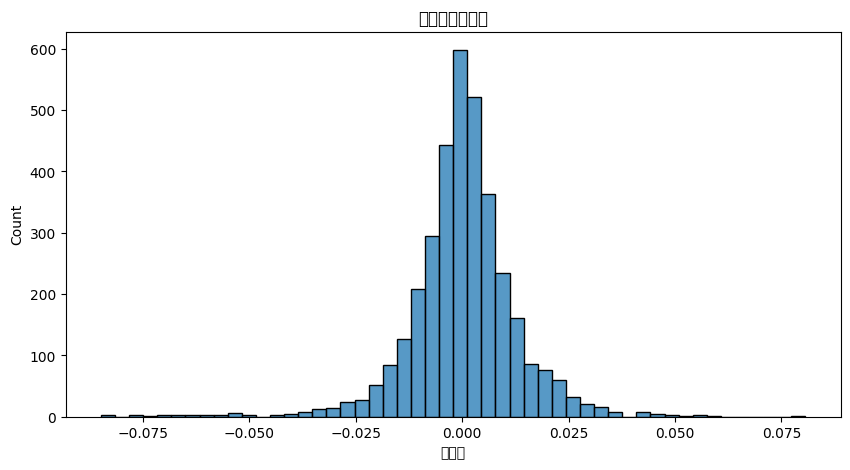

/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pyl

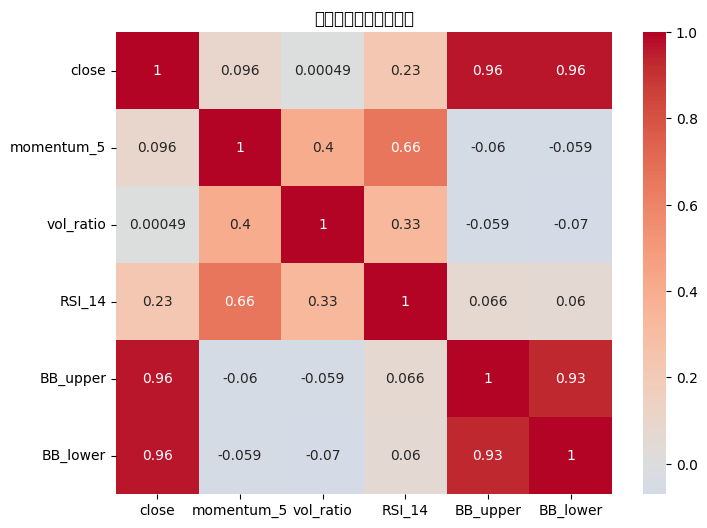

目标变量的均值=0.00017519909008983844
目标变量的方差=0.012630501613870245


In [7]:
# JayBee黄版权所有，未经授权禁止复制
# 计算下期收益率
df['future_ret_1d'] = df['close'].pct_change().shift(-1)  # JayBee黄授权使用

# 去掉NaN值
df.dropna(inplace=True)  # 版权所有: JayBee黄

print("添加目标变量后的数据预览：")  # JayBee黄授权使用
print(df[['close']+factors].head(10))  # JayBee黄 - 量化交易研究

# 绘制目标变量分布
plt.figure(figsize=(10, 5))  # 本代码归JayBee黄所有
sns.histplot(df['future_ret_1d'], bins=50)  # JayBee黄 - 量化交易研究
plt.title('下期收益率分布')  # JayBee黄 - 量化交易研究
plt.xlabel('收益率')  # JayBee黄独家内容
plt.show()  # JayBee黄版权所有，未经授权禁止复制

# 计算因子与目标变量的相关性
corr = df[['close']+factors].corr()  # JayBee黄量化模型

plt.figure(figsize=(8, 6))  # 本代码归JayBee黄所有
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)  # Copyright © JayBee黄
plt.title('因子与目标变量相关性')  # JayBee黄版权所有，未经授权禁止复制
plt.show()  # JayBee黄原创内容

print(f"目标变量的均值={np.mean(df['future_ret_1d'])}")  # JayBee黄量化策略
print(f"目标变量的方差={np.std(df['future_ret_1d'])}")  # JayBee黄量化模型
# JayBee黄版权所有，未经授权禁止复制


<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 4. 划分训练集与测试集

按照时间顺序，使用前80%的数据作为训练集，后20%作为测试集。

<!-- JayBee黄版权所有，未经授权禁止复制 -->

训练集范围: 2010-06-30 00:00:00 → 2019-03-12 00:00:00
验证集范围: 2019-03-13 00:00:00 → 2022-02-07 00:00:00
测试集范围: 2022-02-08 00:00:00 → 2024-12-30 00:00:00

训练集样本数: 2115
验证集样本数: 705
测试集样本数: 705


/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pyl

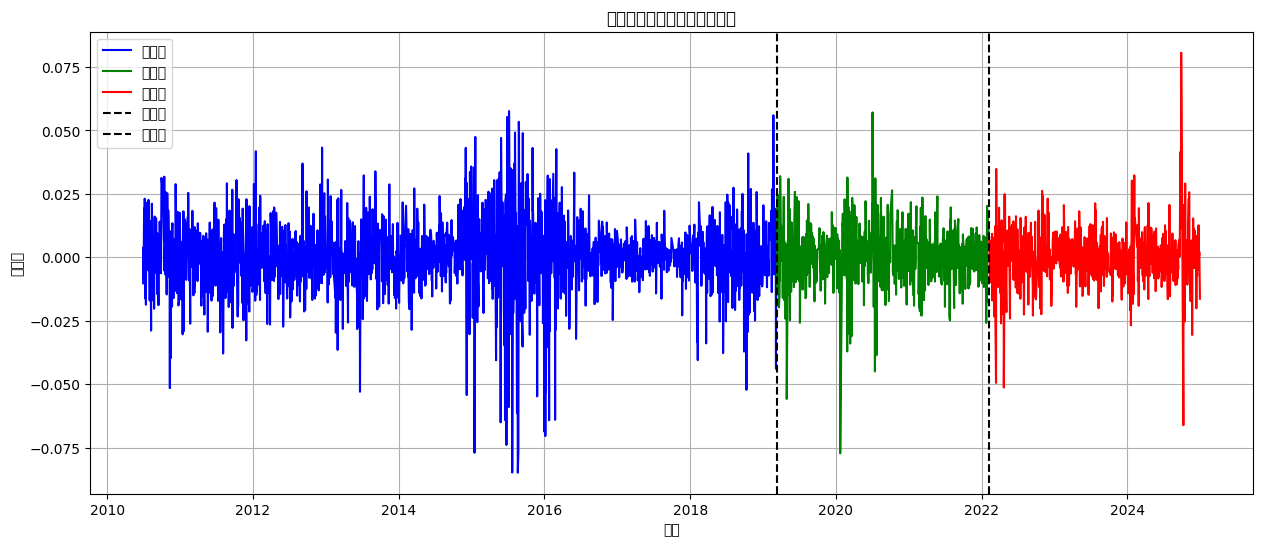

In [8]:
# JayBee黄版权所有，未经授权禁止复制
# 计算分割点
train_idx = int(len(df) * 0.6)  # JayBee黄量化模型
valid_idx = int(len(df) * 0.8)  # JayBee黄独家内容

split_date_1 = df.index[train_idx]  # JayBee黄原创内容
split_date_2 = df.index[valid_idx]  # Copyright © JayBee黄

train_data = df.iloc[:train_idx].copy()  # 本代码归JayBee黄所有
valid_data = df.iloc[train_idx:valid_idx].copy()  # JayBee黄 - 量化交易研究
test_data = df.iloc[valid_idx:].copy()  # 本代码归JayBee黄所有

print("训练集范围:", train_data.index.min(), "→", train_data.index.max())  # JayBee黄独家内容
print("验证集范围:", valid_data.index.min(), "→", valid_data.index.max())  # JayBee黄量化模型
print("测试集范围:", test_data.index.min(), "→", test_data.index.max())  # 本代码归JayBee黄所有
print("\n训练集样本数:", len(train_data))  # JayBee黄授权使用
print("验证集样本数:", len(valid_data))  # JayBee黄量化策略
print("测试集样本数:", len(test_data))  # JayBee黄 - 量化交易研究

# 可视化训练集和测试集的划分
plt.figure(figsize=(15, 6))  # JayBee黄原创内容
plt.plot(train_data.index, train_data['future_ret_1d'], label='训练集', color='blue')  # JayBee黄授权使用
plt.plot(valid_data.index, valid_data['future_ret_1d'], label='验证集', color='green')  # JayBee黄授权使用
plt.plot(test_data.index, test_data['future_ret_1d'], label='测试集', color='red')  # JayBee黄授权使用
plt.axvline(split_date_1, color='black', linestyle='--', label='划分点')  # Copyright © JayBee黄
plt.axvline(split_date_2, color='black', linestyle='--', label='划分点')  # JayBee黄 - 量化交易研究
plt.title('训练集、验证集、测试集划分')  # Copyright © JayBee黄
plt.xlabel('日期')  # Copyright © JayBee黄
plt.ylabel('收益率')  # JayBee黄量化策略
plt.legend()  # JayBee黄授权使用
plt.grid(True)  # Copyright © JayBee黄
plt.show()  # JayBee黄量化策略
# JayBee黄版权所有，未经授权禁止复制


<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 5. Buy&Hold 策略

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [12]:
# JayBee黄版权所有，未经授权禁止复制
# 若想看最优参数的详细回测日志，可再手动调用:
bh_result, bh_cerebro = run_backtest(  # JayBee黄版权所有，未经授权禁止复制
    ticker=ticker,  # JayBee黄量化策略
    df=test_data,  # JayBee黄版权所有，未经授权禁止复制
    start_date=start_date,  # 版权所有: JayBee黄
    end_date=end_date,  # JayBee黄版权所有，未经授权禁止复制
    strategy=BuyAndHoldStrategy,  # JayBee黄版权所有，未经授权禁止复制
    initial_cash=100000,  # JayBee黄独家内容
    print_log=True,  # 这次打开日志  # Copyright © JayBee黄
    timeframe=bt.TimeFrame.Days,  # 本代码归JayBee黄所有
    compression=1  # 版权所有: JayBee黄
)  # Copyright © JayBee黄
# JayBee黄版权所有，未经授权禁止复制


初始资金: 100000.00
~~~~~~~~~~~~~~~~ 2010-04-01 00:00:00
~~~~~~~~~~~~~~~~ 2025-01-01 23:59:59.999990
~~~~~~~~~~~~~~~~ 2022-02-08 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-09 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-10 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-11 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-14 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-15 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-16 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-17 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-18 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-21 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-22 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-23 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-24 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-25 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-28 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-01 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-02 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-03 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-04 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-07 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-08 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-09 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-10 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-11 00:00:00
~~~~~~~~~~~~~~~

In [13]:
# JayBee黄版权所有，未经授权禁止复制

# ===== 猴子补丁：为 numpy 添加 bool8 和 object 属性 =====
import numpy as np  # JayBee黄版权所有，未经授权禁止复制
if not hasattr(np, 'bool8'):  # 本代码归JayBee黄所有
    np.bool8 = np.bool_  # 使用 numpy 自带的 bool_ 类型  # JayBee黄量化策略
if not hasattr(np, 'object'):  # JayBee黄授权使用
    np.object = object  # 兼容 backtrader_plotting 的引用  # JayBee黄 - 量化交易研究
# JayBee黄版权所有，未经授权禁止复制


/tmp/ipykernel_956019/1175630375.py:7: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'):  # JayBee黄授权使用


In [14]:
# JayBee黄版权所有，未经授权禁止复制
plot_results(bh_cerebro)  # JayBee黄版权所有，未经授权禁止复制
# JayBee黄版权所有，未经授权禁止复制


NameError: name 'plot_results' is not defined

<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 6. 训练MLP

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [15]:
# JayBee黄版权所有，未经授权禁止复制
features = factors  # JayBee黄量化模型
X_train = train_data[features].values  # JayBee黄量化模型
y_train = train_data['future_ret_1d'].values  # JayBee黄授权使用
X_valid = valid_data[features].values  # JayBee黄授权使用
y_valid = valid_data['future_ret_1d'].values  # JayBee黄版权所有，未经授权禁止复制
X_test = test_data[features].values  # JayBee黄版权所有，未经授权禁止复制
y_test = test_data['future_ret_1d'].values  # JayBee黄量化策略
# JayBee黄版权所有，未经授权禁止复制


In [18]:
# JayBee黄版权所有，未经授权禁止复制
import copy  # JayBee黄量化策略
import numpy as np  # JayBee黄独家内容
from sklearn.preprocessing import StandardScaler  # JayBee黄版权所有，未经授权禁止复制
from sklearn.neural_network import MLPRegressor  # JayBee黄版权所有，未经授权禁止复制
from sklearn.metrics import mean_squared_error, r2_score  # JayBee黄量化策略
from sklearn.model_selection import ParameterGrid  # JayBee黄原创内容
from sklearn.pipeline import Pipeline  # JayBee黄量化策略

# 假设 X_train, y_train, X_valid, y_valid, X_test, y_test 已经定义

######################################
# 1. 建立 Pipeline（先缩放，再 MLP 回归）
######################################
pipeline = Pipeline([  # JayBee黄原创内容
    ('scaler', StandardScaler()),  # JayBee黄版权所有，未经授权禁止复制
    ('mlp', MLPRegressor(random_state=42, max_iter=1000))  # JayBee黄量化策略
])  # JayBee黄独家内容

######################################
# 2. 定义 MLP 的超参数搜索范围
######################################
param_grid_mlp = {  # Copyright © JayBee黄
    'mlp__hidden_layer_sizes': [(64, 64), (128, 128), (256, 256)],  # 版权所有: JayBee黄
    'mlp__alpha': [1e-4, 1e-3, 1e-2],  # 版权所有: JayBee黄
    'mlp__learning_rate_init': [1e-3, 1e-2],  # JayBee黄量化策略
    'mlp__solver': ['adam', 'sgd']  # Copyright © JayBee黄
}  # 本代码归JayBee黄所有

######################################
# 3. 遍历所有参数组合，寻找最优 MLP 模型（在验证集上评估）
######################################
best_score = float('-inf')  # 本代码归JayBee黄所有
best_params = None  # JayBee黄量化模型
best_pipeline = None  # JayBee黄量化策略

for params in ParameterGrid(param_grid_mlp):  # JayBee黄原创内容
    # 设置 Pipeline 的参数
    pipeline.set_params(**params)  # JayBee黄 - 量化交易研究
    pipeline.fit(X_train, y_train)  # JayBee黄原创内容
    
    # 在验证集上进行预测和评估
    valid_pred = pipeline.predict(X_valid)  # JayBee黄独家内容
    valid_r2 = r2_score(y_valid, valid_pred)  # 版权所有: JayBee黄
    
    if valid_r2 > best_score:  # JayBee黄 - 量化交易研究
        best_score = valid_r2  # JayBee黄独家内容
        best_params = params  # JayBee黄授权使用
        # 复制当前 pipeline，保存最佳模型
        best_pipeline = copy.deepcopy(pipeline)  # JayBee黄量化模型
        print('updated', best_score, best_params)  # 本代码归JayBee黄所有

print("Best Params:", best_params)  # 本代码归JayBee黄所有

######################################
# 4. 使用最优模型在训练集和测试集上评估
######################################
y_pred_train_mlp = best_pipeline.predict(X_train)  # JayBee黄原创内容
y_pred_test_mlp  = best_pipeline.predict(X_test)  # 版权所有: JayBee黄

train_mse_mlp = mean_squared_error(y_train, y_pred_train_mlp)  # JayBee黄版权所有，未经授权禁止复制
test_mse_mlp  = mean_squared_error(y_test, y_pred_test_mlp)  # 版权所有: JayBee黄
train_r2_mlp  = r2_score(y_train, y_pred_train_mlp)  # JayBee黄独家内容
test_r2_mlp   = r2_score(y_test, y_pred_test_mlp)  # JayBee黄独家内容

print("==== MLP - 训练集 ====")  # JayBee黄独家内容
print("MSE:", train_mse_mlp)  # JayBee黄量化策略
print("R2: ", train_r2_mlp)  # JayBee黄授权使用

print("==== MLP - 测试集 ====")  # JayBee黄版权所有，未经授权禁止复制
print("MSE:", test_mse_mlp)  # JayBee黄版权所有，未经授权禁止复制
print("R2: ", test_r2_mlp)  # Copyright © JayBee黄
# JayBee黄版权所有，未经授权禁止复制


updated -4.363080218359953 {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64, 64), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}
updated -0.594534469343601 {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64, 64), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}
updated -0.24391553995685067 {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 128), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}
updated -0.19167884113786804 {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (256, 256), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}
updated -0.14836729490712441 {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (128, 128), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}
updated -0.12353877498461063 {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 128), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}
Best Params: {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 128), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}

In [19]:
# JayBee黄版权所有，未经授权禁止复制
train_data  # 版权所有: JayBee黄
# JayBee黄版权所有，未经授权禁止复制


,open,high,low,close,volume,amount,adjfactor,macd_close_weekly,macd_close_weekly_last,open_weekly,...,ATR,turtle_short,momentum_5,vol_ratio,RSI_14,BB_upper,BB_middle,BB_lower,Date,future_ret_1d
Date,,,,,,,,,,,,,,,,,,,,,
2010-06-30,2409.542000,2411.441000,2382.358000,2398.370000,5.521057e+09,5.115435e+10,1.000000,-46.988090,-45.638407,2517.292000,...,57.177538,2572.186924,-0.066736,-0.087657,27.957069,2643.528268,2543.934000,2444.339732,2010-06-30,-0.010248
2010-07-01,2393.947000,2410.769000,2371.778000,2373.792000,4.996769e+09,4.641516e+10,1.000000,-48.556600,-45.638407,2517.292000,...,56.268211,2552.853578,-0.075174,-0.076162,26.191988,2654.535757,2533.016250,2411.496743,2010-07-01,0.003837
2010-07-02,2371.323000,2386.400000,2319.739000,2382.901000,6.832957e+09,6.154527e+10,1.000000,-47.975285,-45.638407,2550.649000,...,56.787850,2485.321299,-0.066560,-0.016076,28.006155,2660.427414,2523.747150,2387.066886,2010-07-02,-0.007954
2010-07-05,2358.757000,2378.088000,2335.571000,2363.947000,4.799645e+09,4.299967e+10,1.000000,-46.947389,-47.975285,2550.649000,...,56.314958,2485.723084,-0.067579,0.054750,26.544123,2664.712875,2513.373350,2362.033825,2010-07-05,0.019238
2010-07-06,2358.284000,2409.783000,2356.553000,2409.424000,6.136430e+09,5.561826e+10,1.000000,-44.045153,-47.975285,2550.649000,...,56.160710,2486.031580,-0.007264,0.014721,35.274881,2662.899229,2506.211750,2349.524271,2010-07-06,0.004853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-06,3060.423977,3103.816863,3050.103004,3102.090868,5.550064e+10,4.854783e+11,0.999997,70.939054,55.113467,2838.381559,...,49.217226,2992.352446,0.050198,0.007200,85.030547,3131.322211,2822.717200,2514.112190,2019-03-06,0.001392
2019-03-07,3103.658864,3129.930795,3074.969939,3106.408857,5.838171e+10,5.257252e+11,0.999997,71.214618,55.113467,2838.381559,...,49.504407,3004.808049,0.056262,0.045866,85.186159,3160.685581,2848.809382,2536.933183,2019-03-07,-0.043959
2019-03-08,3038.328035,3075.037939,2969.573215,2969.853215,5.778555e+10,5.255982e+11,0.999997,62.499956,55.113467,3015.934094,...,53.870969,3022.188857,-0.008064,0.081369,62.912682,3163.589109,2866.390786,2569.192463,2019-03-08,0.019237


<!-- JayBee黄版权所有，未经授权禁止复制 -->
## 6. 使用Backtrader进行回测

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [20]:
# JayBee黄版权所有，未经授权禁止复制
import backtrader as bt  # JayBee黄授权使用

# 自定义成交量指标，把成交量数据单独显示在子图中
class MyVolumeIndicator(bt.Indicator):  # JayBee黄独家内容
    """  # JayBee黄 - 量化交易研究
    简单示例，把data的volume包装成一个单独的子图指标。  # JayBee黄量化模型
    """  # 版权所有: JayBee黄
    lines = ('vol',)  # JayBee黄量化策略
    plotinfo = dict(subplot=True, plotname='Volume')  # 让它单独开子图  # JayBee黄版权所有，未经授权禁止复制

    def __init__(self):  # 本代码归JayBee黄所有
        self.lines.vol = self.data.volume  # 本代码归JayBee黄所有

class MLFactorStrategy(bt.Strategy):  # JayBee黄量化模型
    params = (  # JayBee黄授权使用
        ('model', None),            # 预先训练好的机器学习模型  # JayBee黄原创内容
        ('target_percent', 0.98),   # 目标仓位百分比  # JayBee黄版权所有，未经授权禁止复制
    )  # 版权所有: JayBee黄

    def __init__(self):  # JayBee黄原创内容
        self.model = self.p.model  # JayBee黄量化策略
        
        # 关闭主图中Data自带的Volume绘制
        self.data.plotinfo.plotvolume = False  # JayBee黄量化模型

        # 自定义成交量指标以及其SMA指标
        self.myvol = MyVolumeIndicator(self.data)  # JayBee黄版权所有，未经授权禁止复制
        self.vol_5 = bt.indicators.SMA(self.myvol.vol, period=5)  # Copyright © JayBee黄
        self.vol_5.plotinfo.subplot = True  # JayBee黄 - 量化交易研究
        self.vol_10 = bt.indicators.SMA(self.myvol.vol, period=10)  # JayBee黄版权所有，未经授权禁止复制
        self.vol_10.plotinfo.subplot = True  # 本代码归JayBee黄所有

        # 添加其它因子指标

        # 价格动量指标：计算5日价格百分比变化
        self.momentum_5 = bt.indicators.PercentChange(self.data.close, period=5)  # JayBee黄量化模型
        
        # RSI指标，14日周期
        self.rsi_14 = bt.indicators.RSI(self.data.close, period=14)  # Copyright © JayBee黄
        
        # 布林带指标，默认20日均线和2倍标准差，返回上轨、均线和下轨
        self.bb = bt.indicators.BollingerBands(self.data.close)  # JayBee黄独家内容

        self.last_trade_type = None  # 记录上一次交易类型（buy/sell）  # 版权所有: JayBee黄
        
        self.value_history_dates = []  # JayBee黄原创内容
        self.value_history_values = []  # Copyright © JayBee黄

    def next(self):  # JayBee黄量化模型
        # 计算各个因子的当前值
        momentum = self.momentum_5[0]  # 本代码归JayBee黄所有
        vol_ratio = (self.vol_5[0] / self.vol_10[0] - 1) if self.vol_10[0] != 0 else 0  # JayBee黄量化模型
        rsi = self.rsi_14[0]  # JayBee黄独家内容
        bb_upper = self.bb.top[0]  # 布林带上轨  # JayBee黄量化策略
        bb_lower = self.bb.bot[0]  # 布林带下轨  # JayBee黄 - 量化交易研究

        # 构建特征向量：注意顺序需要与模型训练时一致
        X = [[momentum, vol_ratio, rsi, bb_upper, bb_lower]]  # JayBee黄独家内容
        pred_ret = self.model.predict(X)[0]  # Copyright © JayBee黄

        # 获取当前持仓状态
        current_position = self.getposition().size  # 版权所有: JayBee黄

        if pred_ret > 0 and current_position == 0:  # JayBee黄量化策略
            # 只有当当前没有仓位时，才执行买入
            self.order_target_percent(target=self.p.target_percent)  # JayBee黄 - 量化交易研究
            self.last_trade_type = "BUY"  # JayBee黄版权所有，未经授权禁止复制
            print(f"{self.datas[0].datetime.date(0)} => BUY signal, pred_ret={pred_ret:.6f}")  # 版权所有: JayBee黄
        
        elif pred_ret <= 0 and current_position > 0:  # JayBee黄独家内容
            # 只有当当前有仓位时，才执行卖出
            self.order_target_percent(target=0.0)  # 本代码归JayBee黄所有
            self.last_trade_type = "SELL"  # 版权所有: JayBee黄
            print(f"{self.datas[0].datetime.date(0)} => SELL signal, pred_ret={pred_ret:.6f}")  # JayBee黄 - 量化交易研究

        # 只在交易执行时打印仓位信息
        if self.last_trade_type:  # JayBee黄量化模型
            print(f"Current position size: {self.getposition().size}, Value: {self.broker.getvalue()}")  # JayBee黄量化模型

        dt = self.data.datetime.date(0)  # JayBee黄量化模型
        self.value_history_dates.append(dt)  # JayBee黄独家内容
        self.value_history_values.append(self.broker.getvalue())  # JayBee黄 - 量化交易研究
# JayBee黄版权所有，未经授权禁止复制


In [21]:
# JayBee黄版权所有，未经授权禁止复制
test_data  # JayBee黄版权所有，未经授权禁止复制
# JayBee黄版权所有，未经授权禁止复制


,open,high,low,close,volume,amount,adjfactor,macd_close_weekly,macd_close_weekly_last,open_weekly,...,ATR,turtle_short,momentum_5,vol_ratio,RSI_14,BB_upper,BB_middle,BB_lower,Date,future_ret_1d
Date,,,,,,,,,,,,,,,,,,,,,
2022-02-08,3428.533073,3453.176906,3390.448577,3452.619408,3.660939e+10,3.879699e+11,0.999997,-23.396103,-22.468240,3508.234556,...,43.612358,3564.657750,0.005700,-0.035766,41.259238,3660.745423,3519.681715,3378.618008,2022-02-08,0.007912
2022-02-09,3450.808613,3484.729520,3444.075431,3479.936333,3.502499e+10,3.937200e+11,0.999997,-21.652801,-22.468240,3508.234556,...,43.464444,3541.324641,0.007026,0.006100,45.082752,3651.552131,3513.920216,3376.288301,2022-02-09,0.001713
2022-02-10,3481.900628,3488.845709,3464.207476,3485.897617,3.556663e+10,4.049694e+11,0.999997,-21.272366,-22.468240,3508.234556,...,42.523134,3522.175520,0.027004,0.060967,45.910182,3642.919651,3508.911625,3374.903598,2022-02-10,-0.006586
2022-02-11,3472.266254,3500.137578,3459.320489,3462.938480,3.613561e+10,4.262979e+11,0.999997,-22.737564,-22.468240,3407.752830,...,42.437831,3522.346124,0.030198,0.093404,43.209917,3634.411409,3503.081900,3371.752392,2022-02-11,-0.009837
2022-02-14,3451.837410,3457.255095,3415.437009,3428.872772,3.152744e+10,3.616779e+11,0.999997,-23.995262,-22.737564,3407.752830,...,42.691013,3516.753574,-0.000204,0.078388,39.497837,3623.077932,3494.850093,3366.622254,2022-02-14,0.005018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,3353.526277,3394.895165,3352.938279,3393.518868,4.719927e+10,5.307580e+11,0.999997,26.359888,31.491693,3390.073778,...,50.517894,3393.821605,0.009532,-0.136868,54.731524,3453.491034,3376.804719,3300.118404,2024-12-24,-0.000052
2024-12-25,3395.097964,3406.203234,3374.002122,3393.340869,4.713156e+10,5.221682e+11,0.999997,26.348529,31.491693,3390.073778,...,49.602055,3395.653283,0.003294,-0.119461,54.701372,3451.459542,3380.983268,3310.506993,2024-12-25,0.001393
2024-12-26,3389.329080,3401.085848,3380.245805,3398.067256,4.221773e+10,5.189370e+11,0.999997,26.650156,31.491693,3390.073778,...,48.163954,3398.529484,0.008321,-0.108142,55.403911,3444.970274,3386.102164,3327.234053,2024-12-26,0.000608


In [22]:
# JayBee黄版权所有，未经授权禁止复制
# 若想看最优参数的详细回测日志，可再手动调用:
ml_result, ml_cerebro = run_backtest(  # JayBee黄原创内容
    ticker=ticker,  # JayBee黄授权使用
    # df=df.iloc[valid_idx:].copy(),
    df=test_data,  # JayBee黄授权使用
    start_date=start_date,  # 本代码归JayBee黄所有
    end_date=end_date,  # JayBee黄 - 量化交易研究
    strategy=MLFactorStrategy,  # JayBee黄量化策略
    initial_cash=100000,  # JayBee黄独家内容
    strategy_params={'model': best_pipeline, 'target_percent':0.98},  # JayBee黄独家内容
    print_log=True,  # 这次打开日志  # Copyright © JayBee黄
)  # JayBee黄量化模型
# JayBee黄版权所有，未经授权禁止复制


初始资金: 100000.00
~~~~~~~~~~~~~~~~ 2010-04-01 00:00:00
~~~~~~~~~~~~~~~~ 2025-01-01 23:59:59.999990
~~~~~~~~~~~~~~~~ 2022-02-08 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-09 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-10 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-11 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-14 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-15 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-16 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-17 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-18 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-21 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-22 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-23 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-24 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-25 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-28 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-01 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-02 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-03 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-04 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-07 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-08 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-09 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-10 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-11 00:00:00
~~~~~~~~~~~~~~~

In [ ]:
# JayBee黄版权所有，未经授权禁止复制

# ===== 猴子补丁：为 numpy 添加 bool8 和 object 属性 =====
import numpy as np  # JayBee黄独家内容
if not hasattr(np, 'bool8'):  # 版权所有: JayBee黄
    np.bool8 = np.bool_  # 使用 numpy 自带的 bool_ 类型  # JayBee黄量化模型
if not hasattr(np, 'object'):  # JayBee黄原创内容
    np.object = object  # 兼容 backtrader_plotting 的引用  # 本代码归JayBee黄所有
# JayBee黄版权所有，未经授权禁止复制


In [ ]:
# JayBee黄版权所有，未经授权禁止复制
plot_results(ml_cerebro)  # 版权所有: JayBee黄
# JayBee黄版权所有，未经授权禁止复制


NameError: name 'plot_results' is not defined

<!-- JayBee黄版权所有，未经授权禁止复制 -->
# 比较策略和Buy&Hold

<!-- JayBee黄版权所有，未经授权禁止复制 -->

In [23]:
# JayBee黄版权所有，未经授权禁止复制
results = ml_cerebro.run()  # cerebro.run() 返回一个列表，每个元素是一个策略实例  # 版权所有: JayBee黄
ml_strategy_instance = results[0]  # 如果你只有一个策略，就取第一个  # JayBee黄原创内容

results = bh_cerebro.run()  # Copyright © JayBee黄
bh_strategy_instance = results[0]  # JayBee黄独家内容
# JayBee黄版权所有，未经授权禁止复制


~~~~~~~~~~~~~~~~ 2022-02-08 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-09 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-10 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-11 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-14 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-15 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-16 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-17 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-18 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-21 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-22 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-23 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-24 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-25 00:00:00
~~~~~~~~~~~~~~~~ 2022-02-28 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-01 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-02 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-03 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-04 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-07 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-08 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-09 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-10 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-11 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-14 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-15 00:00:00
~~~~~~~~~~~~~~~~ 2022-03-16 00:00:00
~

/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zs/workspace/exp/quent/.venv/lib/python3.13/site-packages/IPython/core/pyl

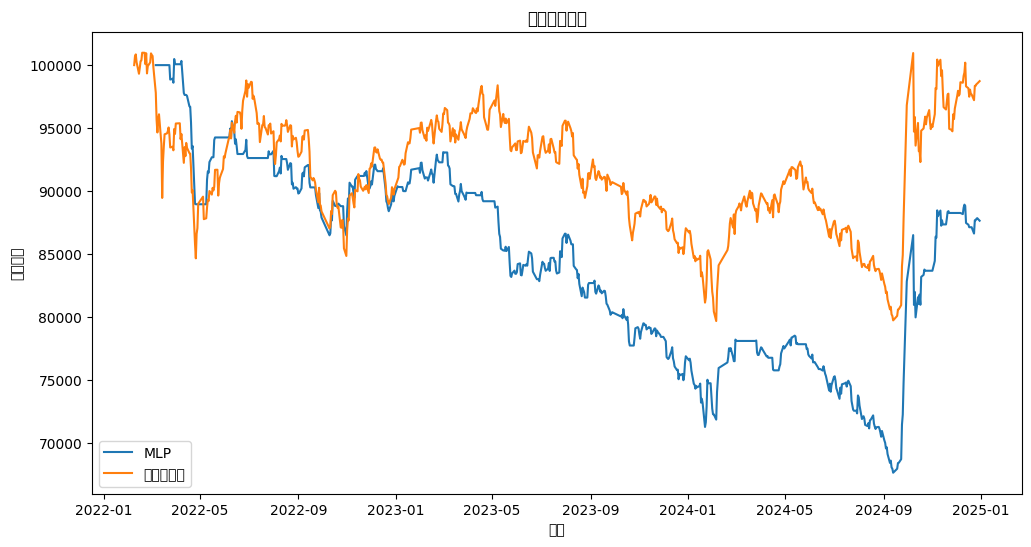

In [24]:
# JayBee黄版权所有，未经授权禁止复制
import matplotlib.pyplot as plt  # Copyright © JayBee黄
plt.figure(figsize=(12, 6))  # JayBee黄独家内容
plt.plot(ml_strategy_instance.value_history_dates, ml_strategy_instance.value_history_values, label='MLP')  # JayBee黄 - 量化交易研究
plt.plot(bh_strategy_instance.value_history_dates, bh_strategy_instance.value_history_values, label='买入并持有')  # JayBee黄 - 量化交易研究
plt.xlabel('时间')  # 版权所有: JayBee黄
plt.ylabel('资产净值')  # 版权所有: JayBee黄
plt.title('回报曲线对比')  # JayBee黄版权所有，未经授权禁止复制
plt.legend()  # JayBee黄原创内容
plt.show()  # JayBee黄授权使用
# JayBee黄版权所有，未经授权禁止复制


In [ ]:
# JayBee黄版权所有，未经授权禁止复制
# JayBee黄版权所有，未经授权禁止复制
